In [1]:
import torch
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from torch.utils.data import random_split
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [4]:
dataset = datasets.ImageFolder(
    root='Data/Faulty_solar_panel',
    transform=transform
)

print(dataset.classes)

['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


In [5]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [6]:
labels = [label for _, label in dataset]
count = Counter(labels)

for i, cls in enumerate(dataset.classes):
    print(f"{cls}: {count[i]}")

Bird-drop: 207
Clean: 193
Dusty: 190
Electrical-damage: 103
Physical-Damage: 69
Snow-Covered: 123


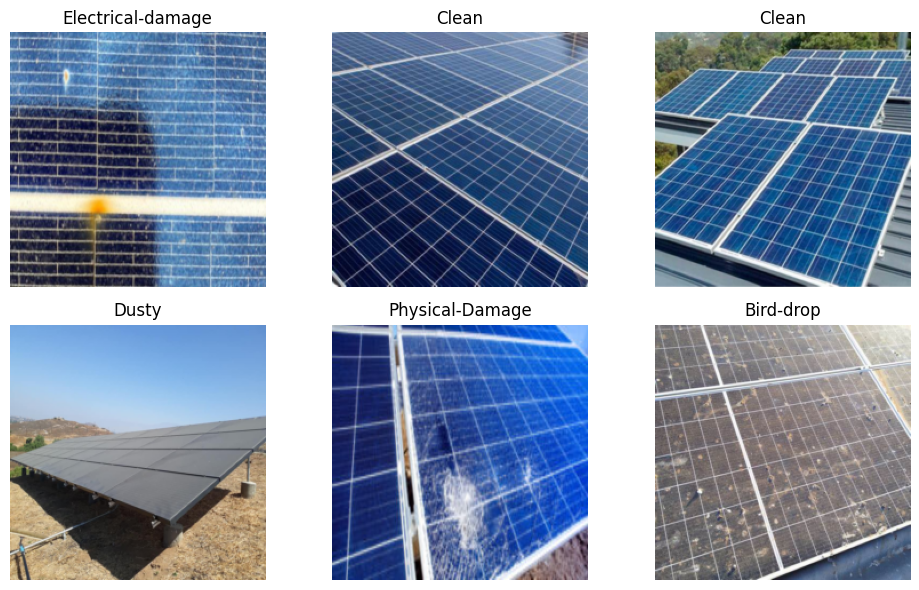

In [7]:
images, labels = next(iter(dataloader))

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0)  
    plt.imshow(img)
    plt.title(dataset.classes[labels[i]])
    plt.axis('off')

plt.tight_layout()

In [8]:
img, label = dataset[0]
print(img.shape) 

torch.Size([3, 224, 224])


Text(0.5, 1.0, 'Pixel Distribution')

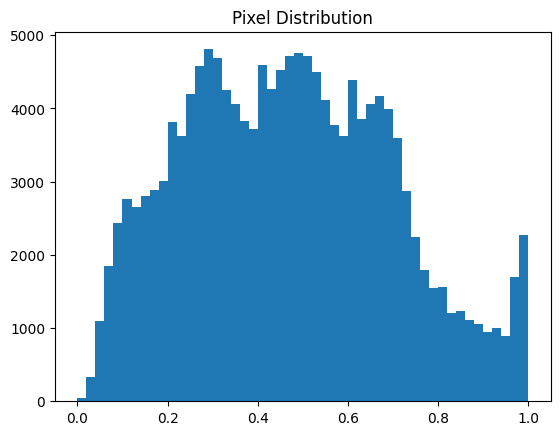

In [9]:
img = images[0].numpy()
plt.hist(img.ravel(), bins=50)
plt.title("Pixel Distribution")

In [10]:
train_size = int(0.9*len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [11]:
len(train_dataset), len(val_dataset)

(796, 89)

In [12]:
train_dataset.dataset.transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

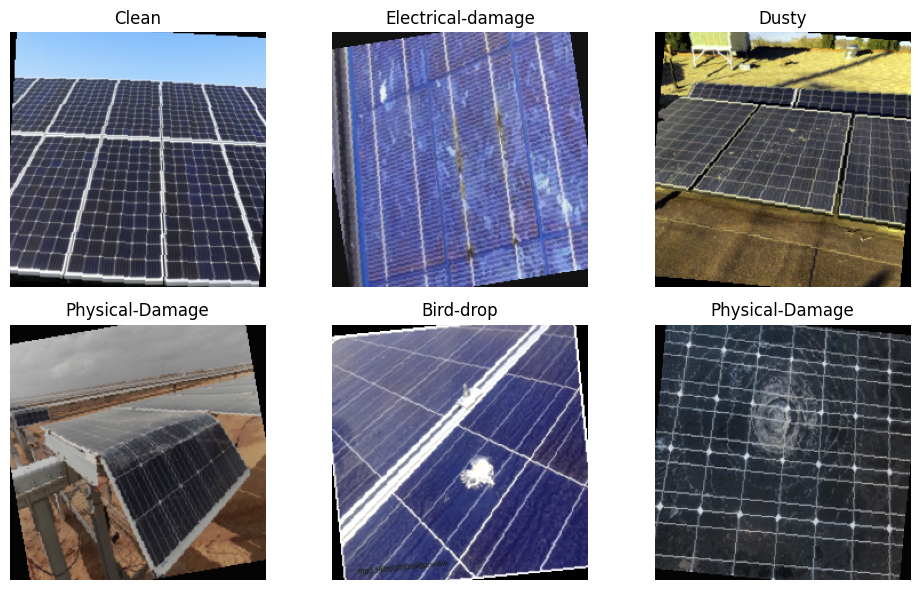

In [13]:
images, labels = next(iter(DataLoader(train_dataset, batch_size=32, shuffle=True)))

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0)  
    plt.imshow(img)
    plt.title(dataset.classes[labels[i]])
    plt.axis('off')

plt.tight_layout()

In [14]:
counts = torch.tensor([184, 173, 171, 95, 63, 110], dtype=torch.float)
weights = 1.0 / counts
weights = (weights / weights.sum() * len(counts)).to(device)

print(weights)

tensor([0.6205, 0.6599, 0.6677, 1.2018, 1.8122, 1.0379], device='cuda:0')


In [15]:
#Hyperparameters
Leaky_ReLU_negative_slope = 0.01
in_channel=3
out_channel = 32

Dropout_rate = 0.18
lr=0.0005
lr_patience = 2
num_epochs = 40

batch_size = 16
patience = 6

kernel_size = 4
stride = 2
padding_count = 1

In [ ]:
class ConditionClassification(nn.Module):
    def __init__(self, in_channel, out_channel, output_size):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, kernel_size=kernel_size, stride=stride, padding=padding_count),
            nn.BatchNorm2d(out_channel),
            nn.LeakyReLU(negative_slope=Leaky_ReLU_negative_slope),
            nn.Dropout2d(Dropout_rate),
            nn.MaxPool2d(2),

            nn.Conv2d(out_channel, out_channel*2, kernel_size=kernel_size, stride=stride, padding=padding_count),
            nn.BatchNorm2d(out_channel*2),
            nn.LeakyReLU(negative_slope=Leaky_ReLU_negative_slope),
            nn.Dropout2d(Dropout_rate),
            nn.MaxPool2d(2),

            nn.Conv2d(out_channel*2, out_channel*4, kernel_size=kernel_size, stride=stride, padding=padding_count),
            nn.BatchNorm2d(out_channel*4),
            nn.LeakyReLU(negative_slope=Leaky_ReLU_negative_slope),
            nn.Dropout2d(Dropout_rate),
            nn.MaxPool2d(2),

            nn.Conv2d(out_channel*4, out_channel*8, kernel_size=kernel_size, stride=stride, padding=padding_count),
            nn.BatchNorm2d(out_channel*8),
            nn.LeakyReLU(negative_slope=Leaky_ReLU_negative_slope),
            nn.Dropout2d(Dropout_rate),
        )

        self.fc = nn.Sequential(
            nn.LazyLinear(512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(negative_slope=Leaky_ReLU_negative_slope),
            nn.Dropout(Dropout_rate),
            nn.Linear(512, output_size)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1) 
        x = self.fc(x)
        return x

In [17]:
model = ConditionClassification(in_channel=in_channel, out_channel=out_channel, output_size=len(dataset.classes))
model=model.to(device)
critertion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.5, patience=lr_patience)

In [18]:
epoch_losses = []
accuracies = []
best_val_loss = float("inf")
counter = 0
train_load = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_load = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
for epoch in range(num_epochs):
#Training 
    model.train()
    running_loss = 0.0
    for images, labels in train_load:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        loss = critertion(output, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)        
    train_loss = running_loss / len(train_dataset)
    epoch_losses.append(train_loss)

# validation
    model.eval()
    correct = 0
    total = 0
    val_loss=0.0
    with torch.no_grad():
        for images, labels in val_load:
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)

            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss = critertion(output, labels)
            val_loss += loss.item()*images.size(0)

    accuracy = 100 * correct / total
    val_loss/=len(val_dataset)
    scheduler.step(val_loss)
    accuracies.append(accuracy)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Acc={accuracy:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter +=1
    if counter >= patience:
        print("Early stopping triggered")
        break


RuntimeError: Given input size: (256x1x1). Calculated output size: (256x0x0). Output size is too small

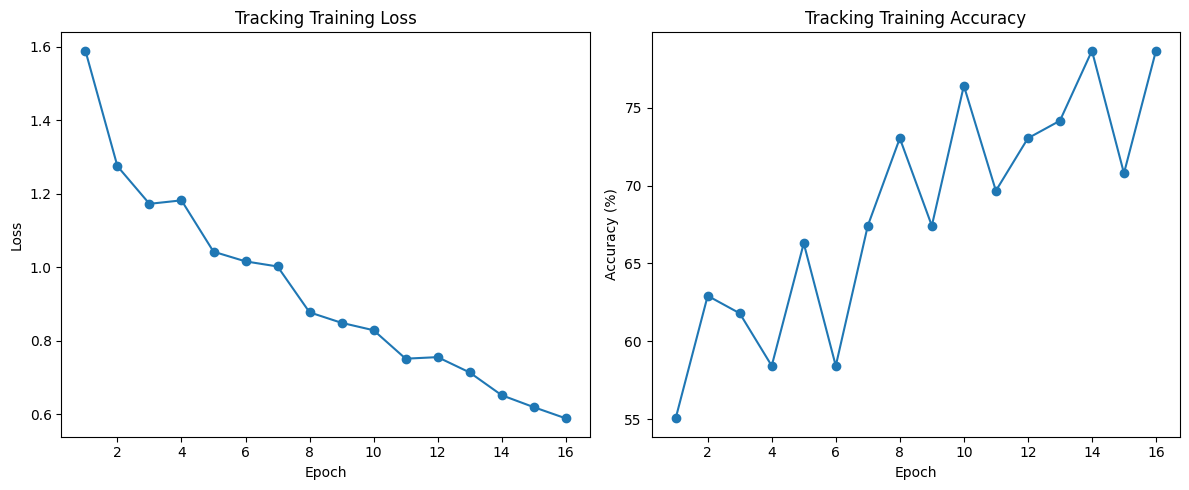

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.title("Tracking Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.subplot(1,2,2)
plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o')
plt.title("Tracking Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()

In [ ]:
with torch.no_grad():
    model.eval()
    correct = 0
    total = 0
    for images, labels in DataLoader(val_dataset, batch_size=16):
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        _, predicted = torch.max(output.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 76.40%


In [ ]:
#torch.save(model.state_dict(), "Models/25.84%_accuracy_model.pth")

In [ ]:
print(torch.unique(predicted, return_counts=True))
print(torch.unique(labels, return_counts=True))
print("Pred:", predicted[:10])
print("True:", labels[:10])

(tensor([0, 1, 2, 3, 5], device='cuda:0'), tensor([3, 1, 2, 2, 1], device='cuda:0'))
(tensor([0, 2, 3, 5], device='cuda:0'), tensor([4, 3, 1, 1], device='cuda:0'))
Pred: tensor([2, 3, 0, 5, 0, 0, 3, 2, 1], device='cuda:0')
True: tensor([2, 3, 0, 5, 0, 0, 2, 2, 0], device='cuda:0')


In [ ]:
all_labels = []
for _, labels in train_load:
    all_labels.append(labels)

all_labels = torch.cat(all_labels)
print(torch.bincount(all_labels))

tensor([188, 173, 170,  96,  58, 111])


✔️ Attention Mechanisms
* SE Blocks (Squeeze-and-Excitation)
* CBAM (Convolutional Block Attention Module)

👉 Helps model focus on important regions of images.

🔹 3. Regularization Techniques

Prevent overfitting while improving generalization.

* Dropout (random neuron deactivation)
* Label Smoothing
* Weight Decay (L2 regularization)
* Stochastic Depth (drop layers randomly in deep nets)